In [1]:
# Environment setup

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ENV = "colab"
    print("Running on Google Colab")
else:
    ENV = "local"
    print("Running locally")


Running on Google Colab


In [2]:
if ENV == "colab":

    print("Install dependencies")
    !pip install -q pytorch-msssim torchsummary

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam

else:

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam

Install dependencies


In [3]:
# Set up the workspace

REPO_DIR = "/content/scimlga2026"

if not os.path.exists(REPO_DIR):
    print("Cloning the SciMLGA 2026 course repository from GitHub...")
    !git clone https://github.com/brunoss-on/scimlga2026.git {REPO_DIR}
    print("Repository successfully cloned!")
else:
    print("Repository already available. Skipping clone.")

Repository already available. Skipping clone.


In [4]:
WORK_DIR = os.path.join(REPO_DIR, "lab02_TreinoRedeModelos")
os.chdir(WORK_DIR)
print("Current directory:", os.getcwd())
print("Current contents:", os.listdir())

Current directory: /content/scimlga2026/lab02_TreinoRedeModelos
Current contents: ['model_teste01.pth', 'treino_rede_modelos.ipynb']


In [5]:
# Load dataset
DATA_FILE = "TirosMods1.zip"
FILE_ID = "1demUCJiQE3ybdl_xpbWTJ-Q00PyBEhnc"

DATA_DIR = os.path.join(REPO_DIR,"resources_GeracaoTiros")

if not os.path.exists(f"{DATA_DIR}/TirosMods1"):
    os.makedirs(DATA_DIR, exist_ok=True)
    !pip -q install gdown
    !gdown "https://drive.google.com/uc?id={FILE_ID}" -O "{DATA_DIR}/{DATA_FILE}"

    !unzip -q -o "{DATA_DIR}/{DATA_FILE}" -d "{DATA_DIR}"
else:
    print("Data already available.")

Data already available.


In [6]:
# Load dataset
DATA_FILE = "Mods1.zip"
FILE_ID = "1NfYKtnY-kkhsbIAQCQ2U0CEBMMvabLGj"

DATA_DIR = os.path.join(REPO_DIR,"resources_GeracaoModelosVel")

if not os.path.exists(f"{DATA_DIR}/Mods1"):
    os.makedirs(DATA_DIR, exist_ok=True)
    !pip -q install gdown
    !gdown "https://drive.google.com/uc?id={FILE_ID}" -O "{DATA_DIR}/{DATA_FILE}"

    !unzip -q -o "{DATA_DIR}/{DATA_FILE}" -d "{DATA_DIR}"
else:
    print("Data already available.")

Data already available.


In [7]:
shot_size = (640,128) #tamanho dos tiros
img_size = (128,128) #tamanho das imagens
n_filters = 12 #número de tiros

In [8]:
data_dir ='../resources_GeracaoTiros/TirosMods1/'
mod_dir = '../resources_GeracaoModelosVel/Mods1/Bin/'
# LOADING PATHS
shot_list = [xn for xn in os.listdir(data_dir) if "shot" in xn]
mod_list = [xn for xn in os.listdir(mod_dir) if "model" in xn]
mod_list.sort()
shot_list.sort()

# LOADING IMAGES

x_data = np.zeros((len(shot_list), n_filters) + img_size)
y_data = np.zeros( (len(shot_list), )+img_size)
for i in range(len(shot_list)):
    ent=np.load(data_dir + shot_list[i])
    sai=np.load(mod_dir + mod_list[i])
#    ent.shape
    x_data[i,:,:,:] = np.transpose(ent[:,:,0:640:5],(0,2,1))
    y_data[i,:,:] = sai[:,:]

In [9]:
def normalize_function(img):
    imag = img
    vis_p_max = np.percentile(imag, 96)
    vis_p_min = -np.percentile(imag, 96)
    clip=(vis_p_max - vis_p_min)/2
    imag = np.clip(imag,-clip,clip)
    imag=(imag+clip)/(2*clip)
    return imag

In [10]:
for filt in range(n_filters):
    x_data[:, filt,:, :] = normalize_function(x_data[:, filt,:, :])
y_data=y_data/1000 # trata a velocidade como km/s, range de saída menor

In [11]:
np.amin(y_data)

np.float64(1.00798)

In [12]:
y_datan=(y_data-np.amin(y_data))
y_data=y_datan/np.amax(y_datan)

In [13]:
np.amin(y_datan)

np.float64(0.0)

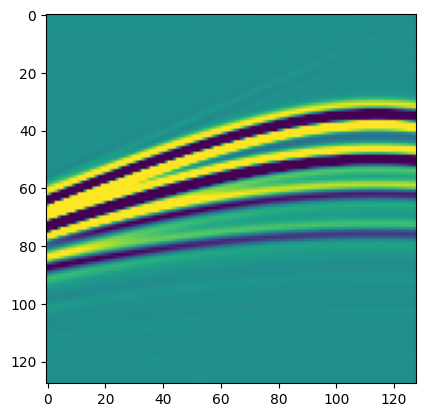

In [14]:
plt.imshow(x_data[20, 11, :, :])

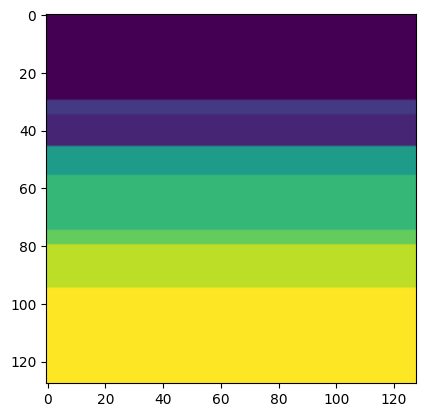

In [15]:
plt.imshow(y_data[10, :, :])

In [16]:
np.amax(y_data)

np.float64(1.0)

In [17]:
EPOCAS=150
BATCH = 8
PATIENCE = 25

In [18]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 batchnorm=True,
                 momentum=0.9):
        super().__init__()
        layers = []
        layers.append(
            nn.Conv2d(in_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=1 - momentum)
            )

        layers.append(nn.ReLU(inplace=True))
        layers.append(
            nn.Conv2d(out_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=0.1)
            )

        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [19]:
class UNetUpConv(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(n_filters * 16,n_filters * 16,kernel_size=3,stride=2, padding=1,output_padding=1)

        self.up7 = nn.ConvTranspose2d(n_filters * 8,n_filters * 8,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4,n_filters * 4,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up9 = nn.ConvTranspose2d(n_filters * 2,n_filters*2,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [20]:
class UNetUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [21]:
class UNetModUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [22]:
class EncDecSig(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        #u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        #u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        #u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return torch.sigmoid(self.out(c9))

In [23]:
class SSIM(nn.Module):
    def __init__(self):
        super().__init__()
    coef = 0.5
    def forward(self,y_true, y_pred):
        loss = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        return loss

In [24]:
class SSIMLossRMSE(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,y_true, y_pred):
        ssim_term = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        l2 = torch.sum((y_true - y_pred) ** 2,dim=1)
        loss =  ssim_term + l2.mean()
        return loss

In [25]:
img_train, x_test, mask_train, y_test = train_test_split( x_data,np.expand_dims(y_data, axis=1),test_size=0.1,random_state=42)
x_train, x_val, y_train, y_val = train_test_split(img_train,mask_train,test_size=1/8,random_state=42)

In [26]:
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images,dtype=torch.float32)
        self.masks = torch.tensor(masks,dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

In [27]:
train_dataset = ImageDataset(x_train,y_train)
val_dataset = ImageDataset(x_val,y_val)
train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False)

In [28]:
model = EncDecSig(in_channels=n_filters, n_filters=16,dropout=0.2,moment=0.2,batchnorm=True)
from torchsummary import summary
summary(model,input_size=(12, 128, 128), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]           4,800
       BatchNorm2d-2         [-1, 16, 128, 128]              32
              ReLU-3         [-1, 16, 128, 128]               0
            Conv2d-4         [-1, 16, 128, 128]           6,400
       BatchNorm2d-5         [-1, 16, 128, 128]              32
              ReLU-6         [-1, 16, 128, 128]               0
       Conv2dBlock-7         [-1, 16, 128, 128]               0
         MaxPool2d-8           [-1, 16, 64, 64]               0
         Dropout2d-9           [-1, 16, 64, 64]               0
           Conv2d-10           [-1, 32, 64, 64]          12,800
      BatchNorm2d-11           [-1, 32, 64, 64]              64
             ReLU-12           [-1, 32, 64, 64]               0
           Conv2d-13           [-1, 32, 64, 64]          25,600
      BatchNorm2d-14           [-1, 32,

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
#criterion = nn.MSELoss()
criterion= SSIMLossRMSE()
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)
best_val_loss = float("inf")

counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"model_teste01.pth")
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break

Epoch [1/150] loss=0.2360 mae=0.1862 val_loss=0.1572 val_mae=0.1235
Val loss melhorou para 0.157203. Salvando modelo.
Epoch [2/150] loss=0.1545 mae=0.1262 val_loss=0.1333 val_mae=0.0956
Val loss melhorou para 0.133263. Salvando modelo.
Epoch [3/150] loss=0.1372 mae=0.1053 val_loss=0.1279 val_mae=0.0976
Val loss melhorou para 0.127946. Salvando modelo.
Epoch [4/150] loss=0.1308 mae=0.0983 val_loss=0.1289 val_mae=0.0985
Val loss não melhorou. Patience 1/25
Epoch [5/150] loss=0.1255 mae=0.0919 val_loss=0.1233 val_mae=0.0819
Val loss melhorou para 0.123326. Salvando modelo.
Epoch [6/150] loss=0.1220 mae=0.0885 val_loss=0.1205 val_mae=0.0823
Val loss melhorou para 0.120460. Salvando modelo.
Epoch [7/150] loss=0.1211 mae=0.0866 val_loss=0.1181 val_mae=0.0820
Val loss melhorou para 0.118121. Salvando modelo.
Epoch [8/150] loss=0.1182 mae=0.0832 val_loss=0.1165 val_mae=0.0745
Val loss melhorou para 0.116529. Salvando modelo.
Epoch [9/150] loss=0.1173 mae=0.0822 val_loss=0.1169 val_mae=0.0777
V

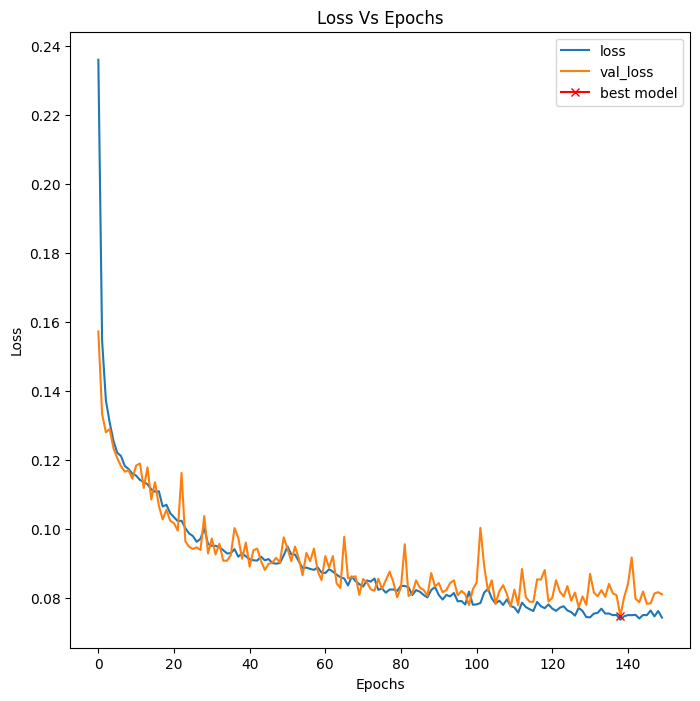

In [30]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

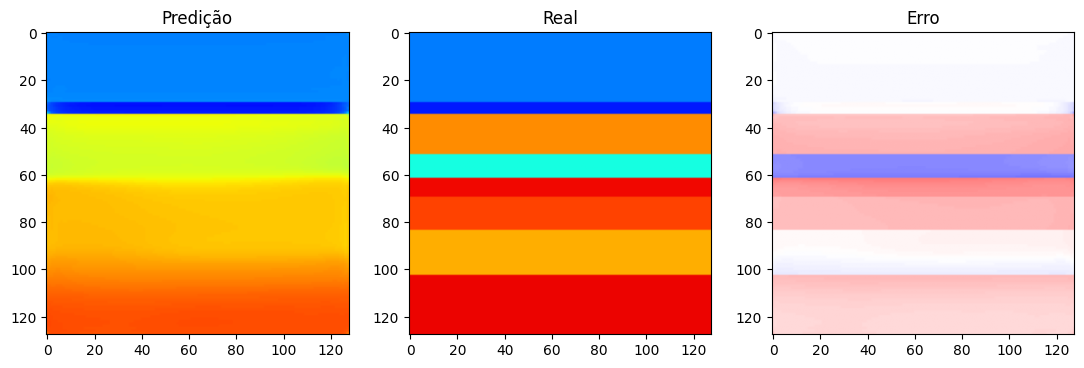

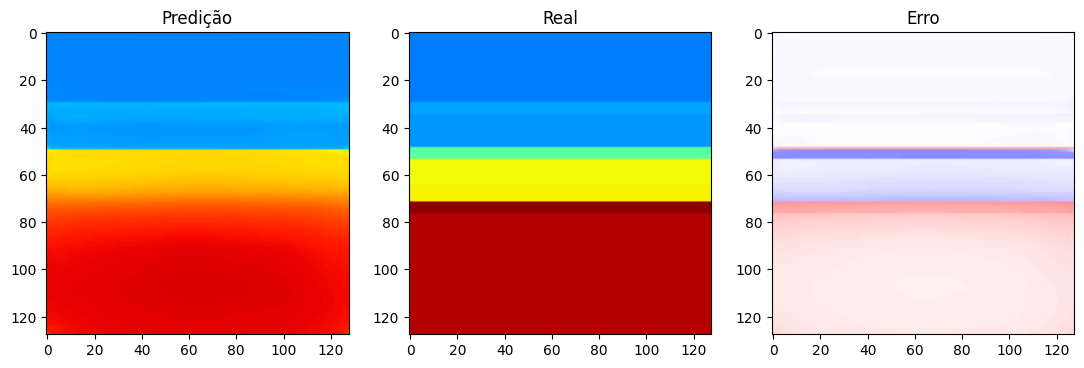

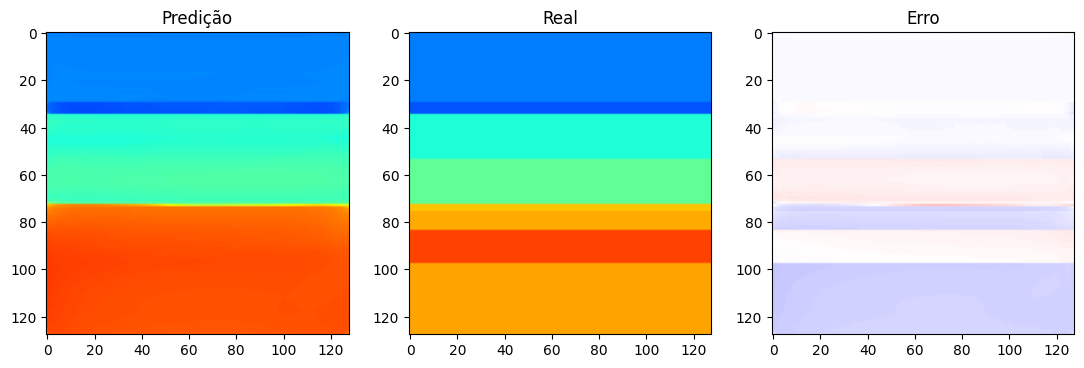

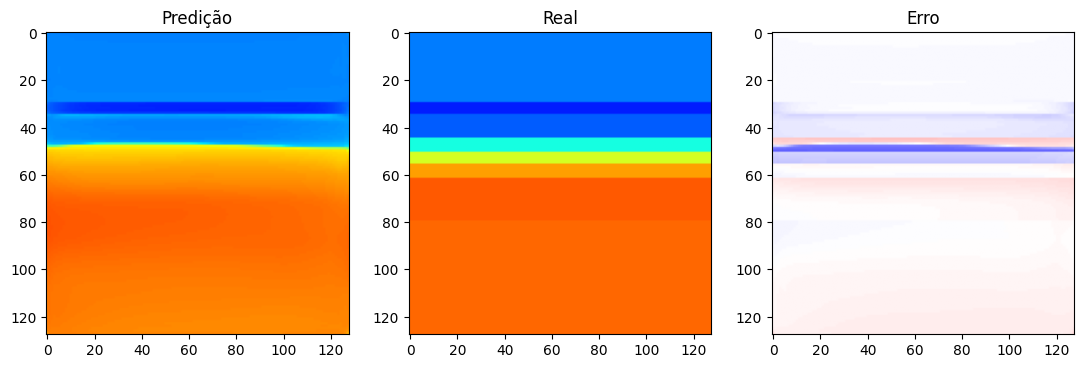

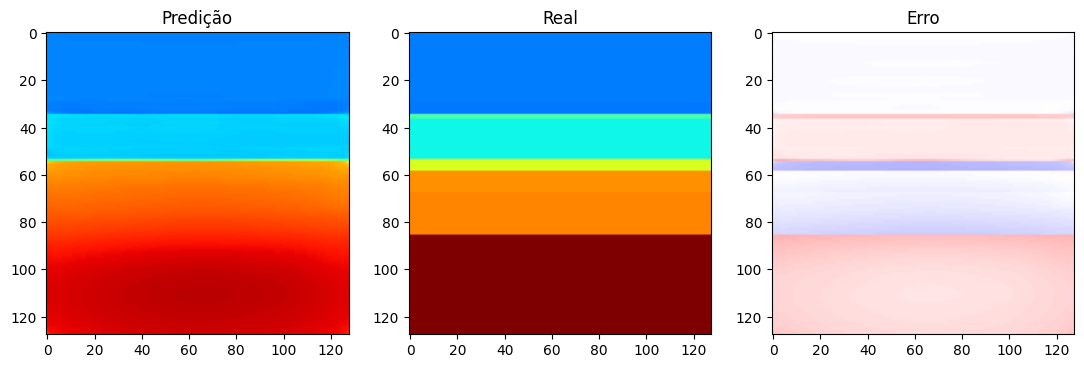

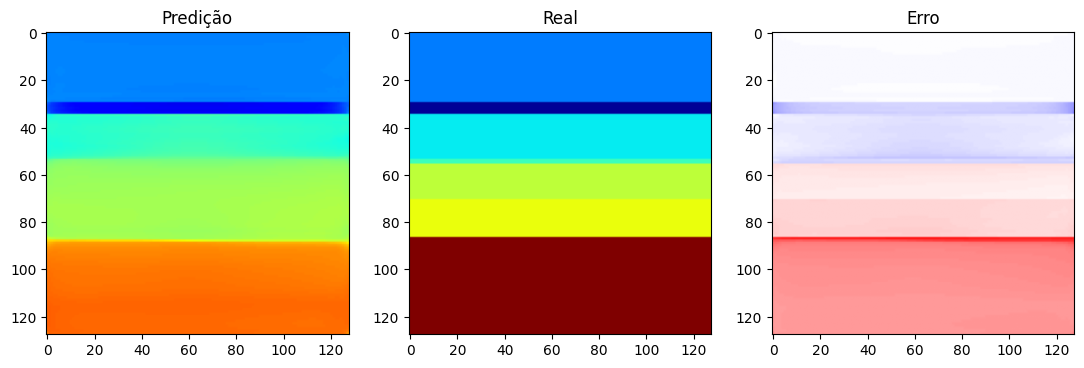

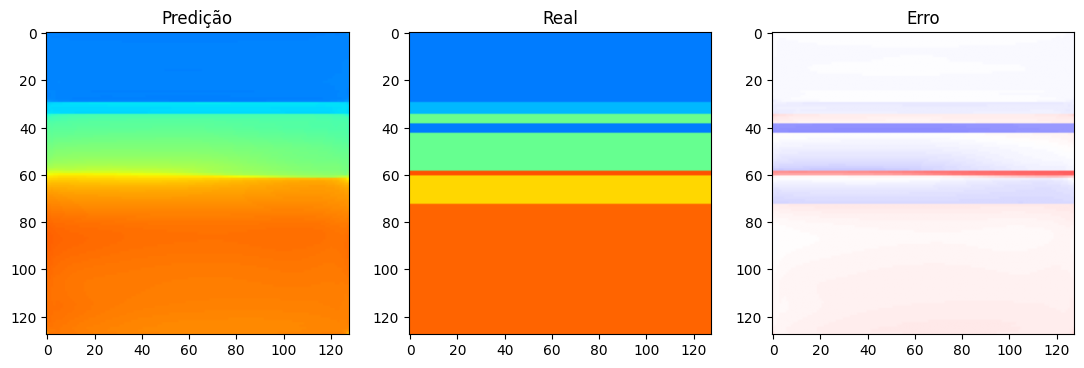

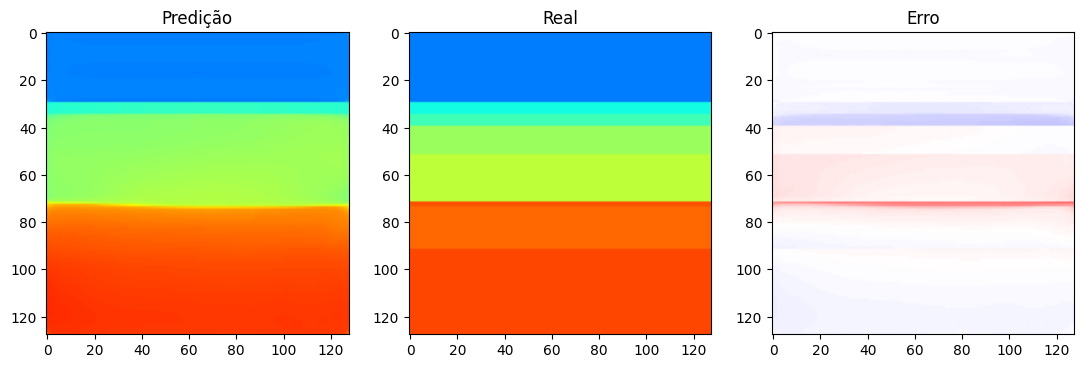

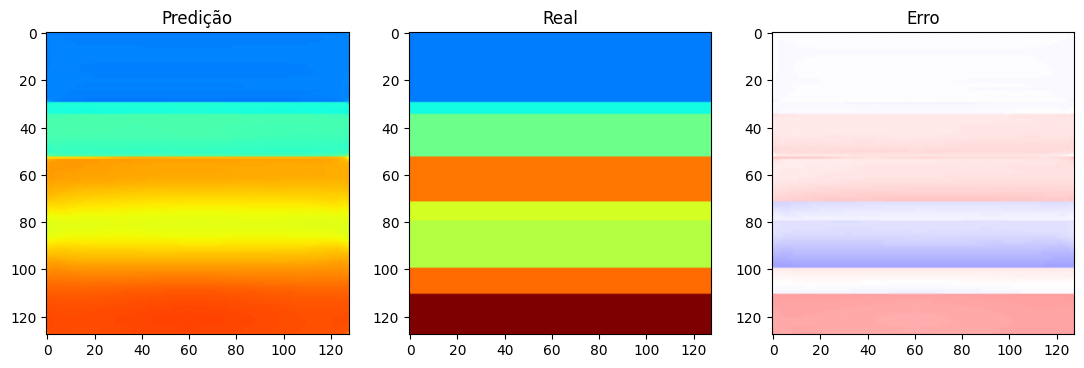

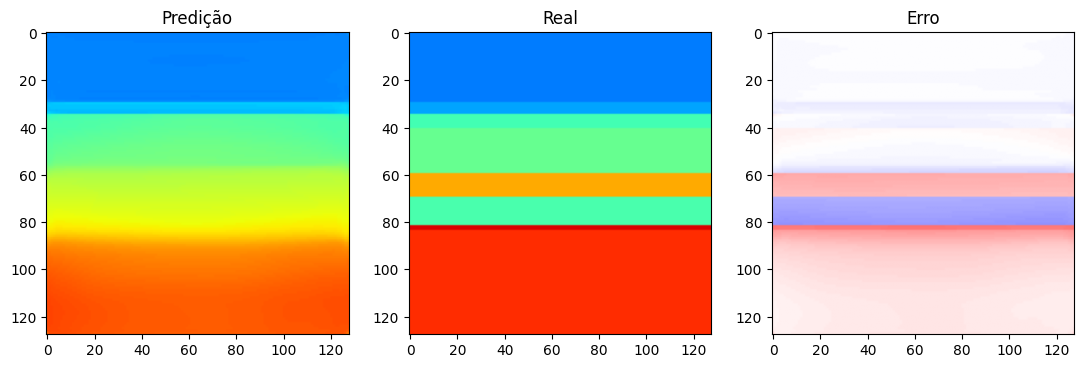

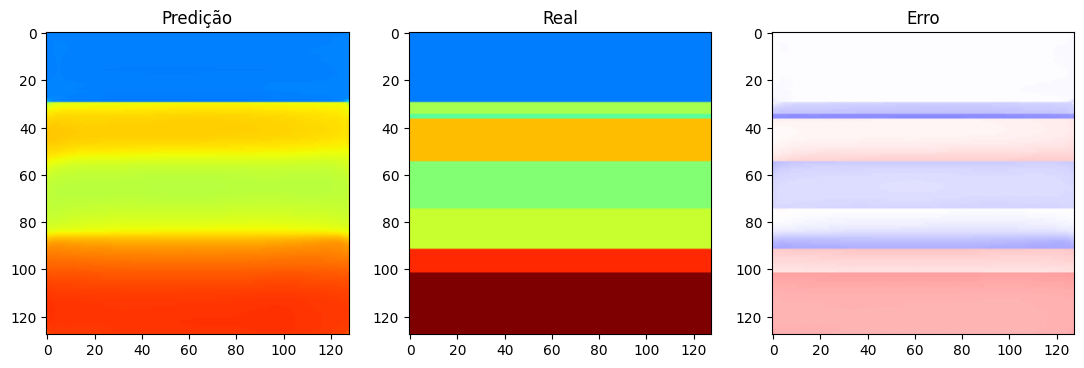

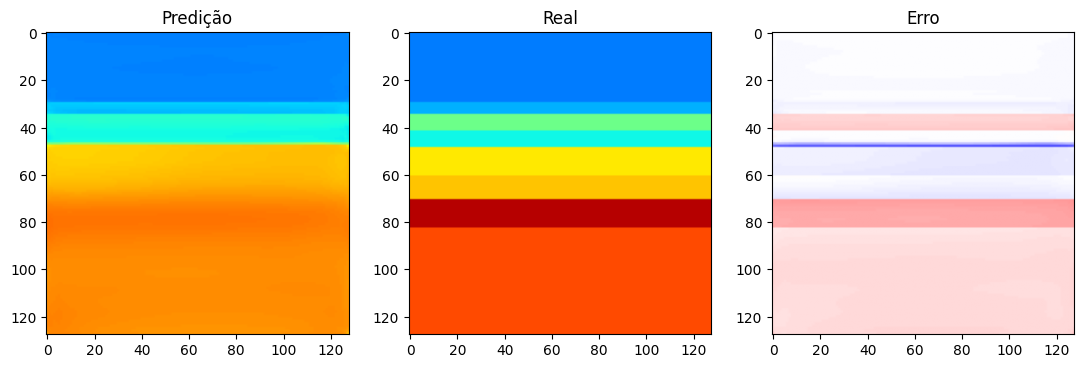

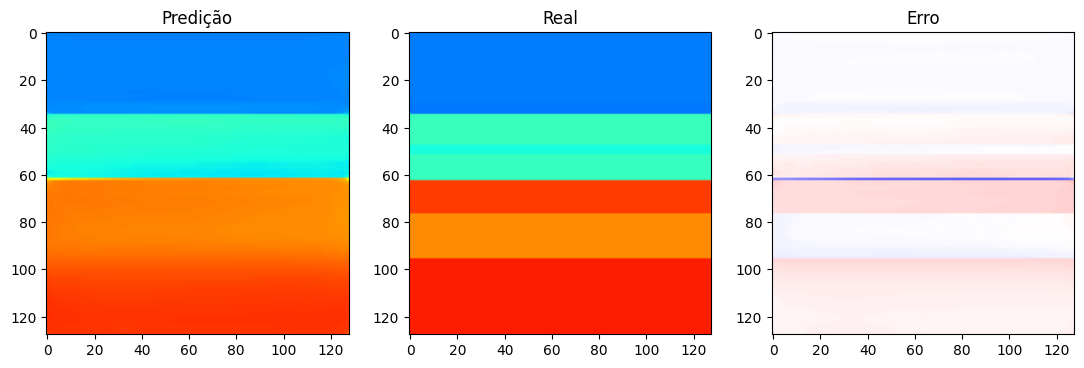

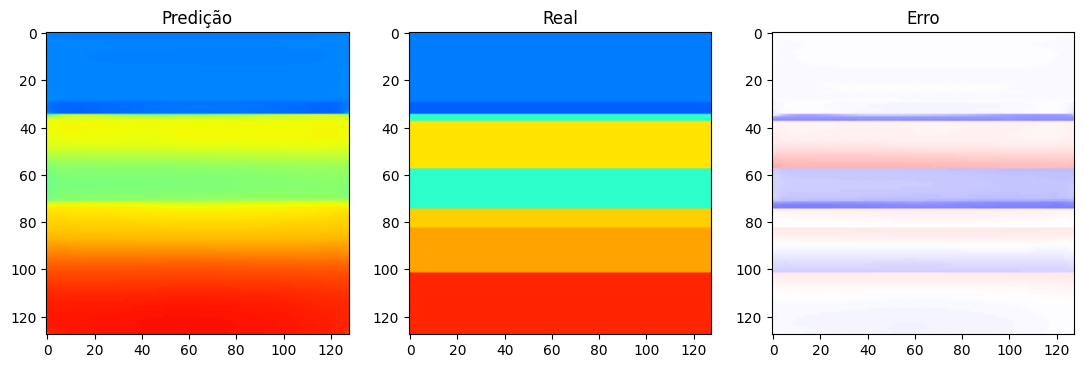

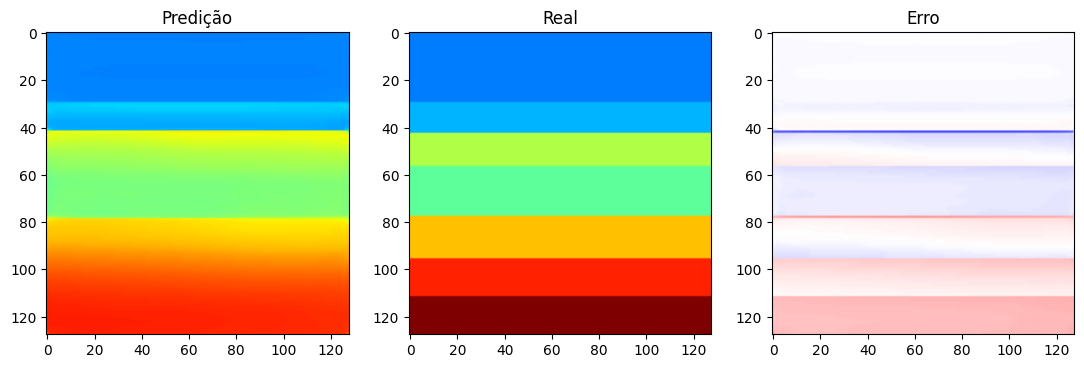

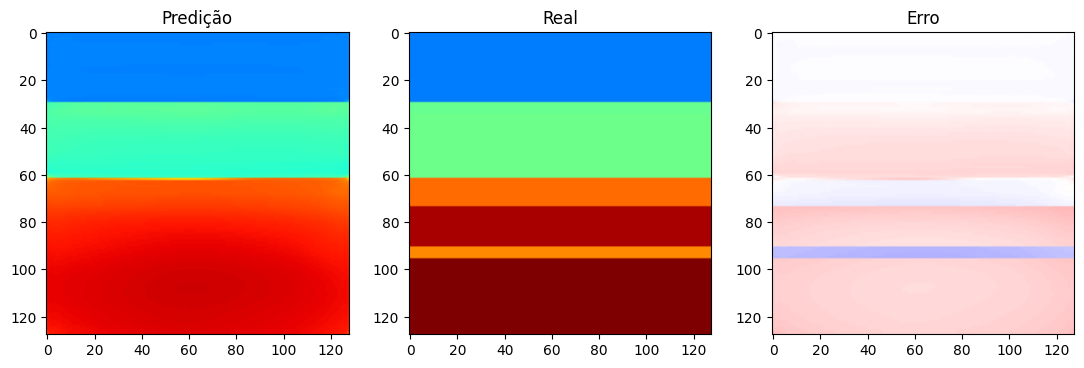

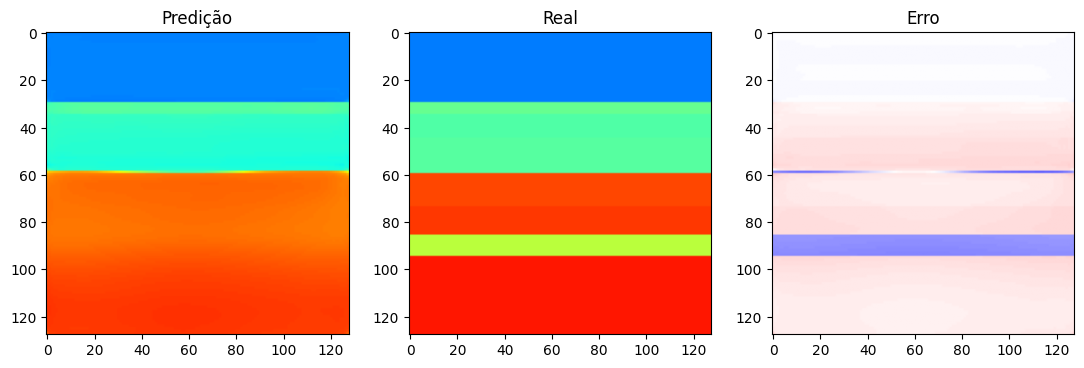

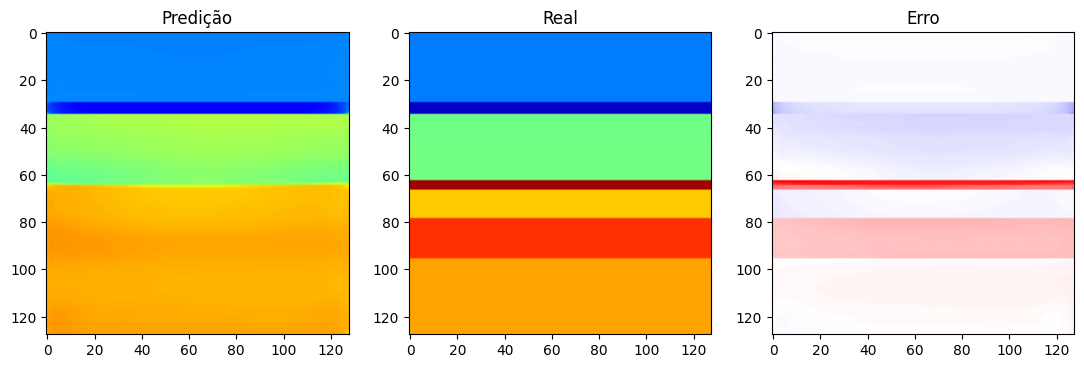

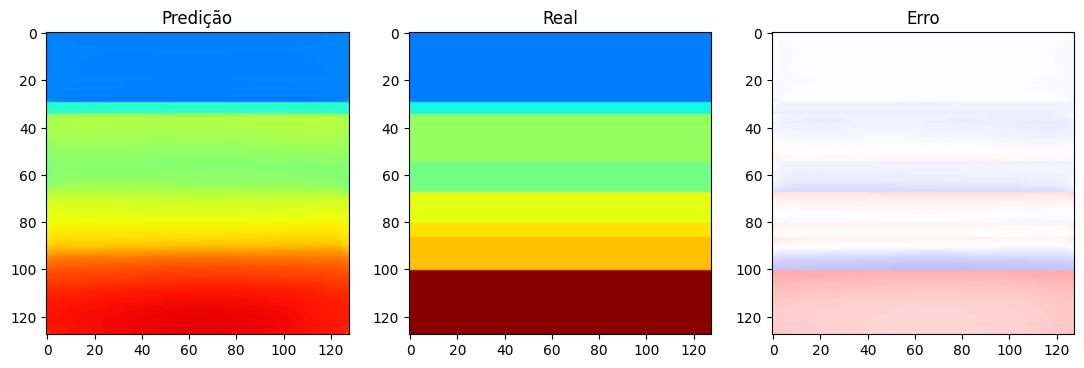

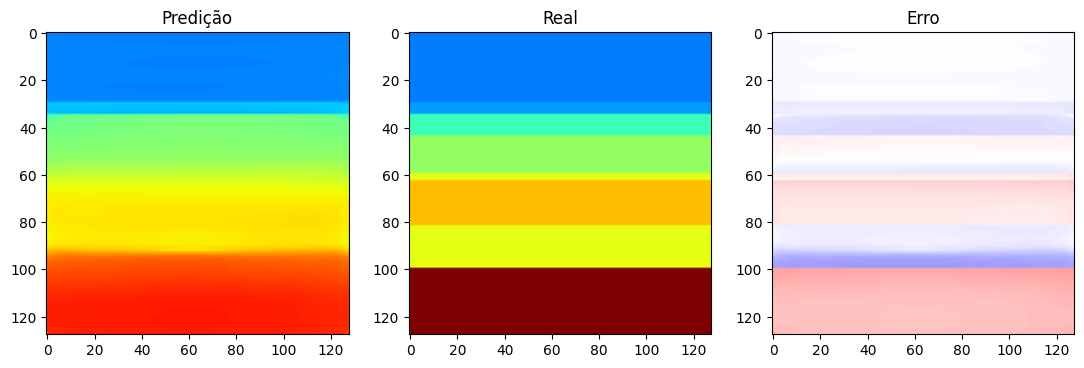

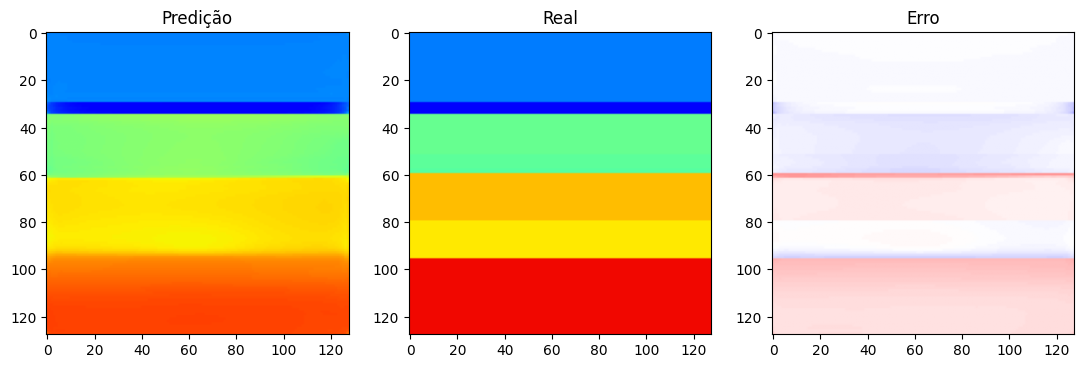

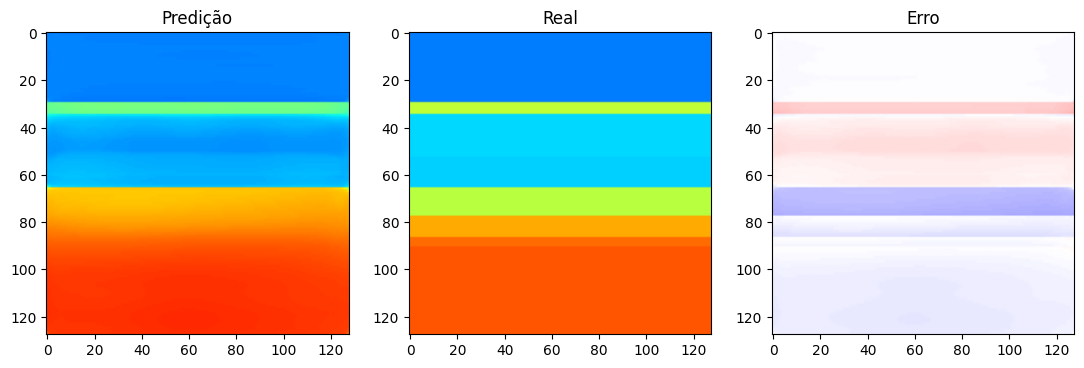

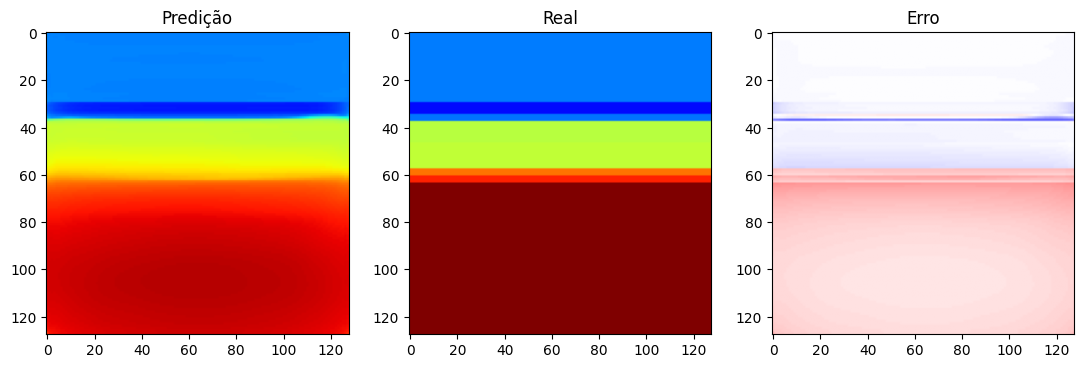

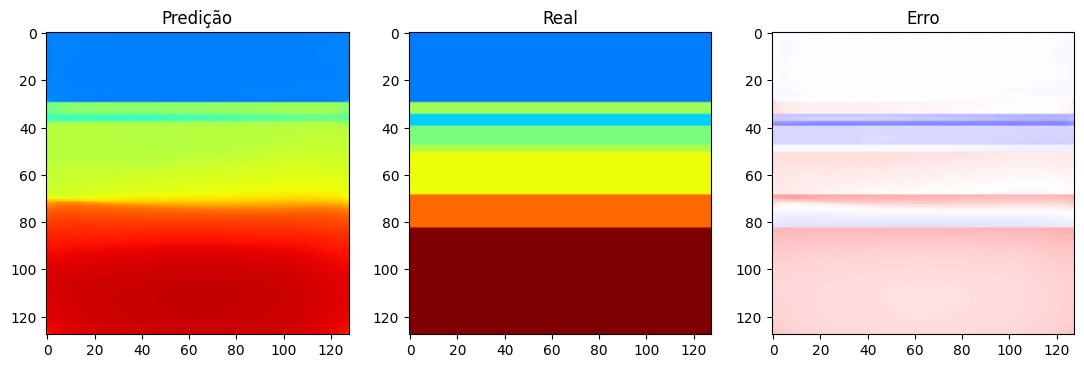

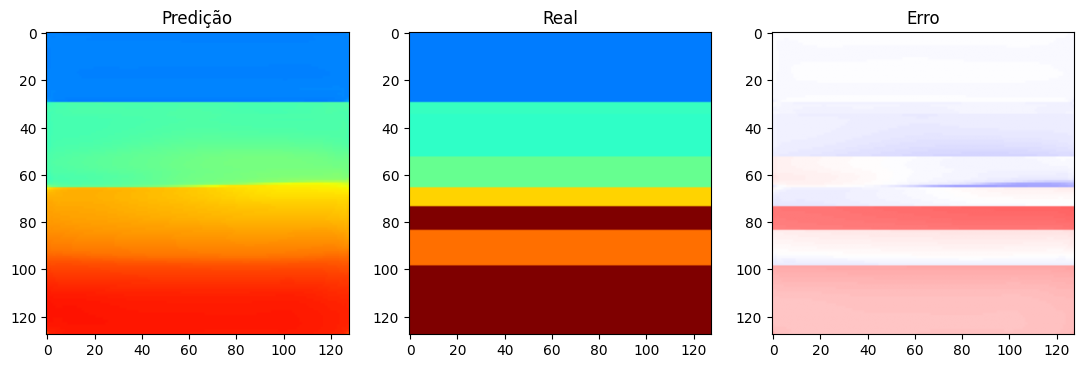

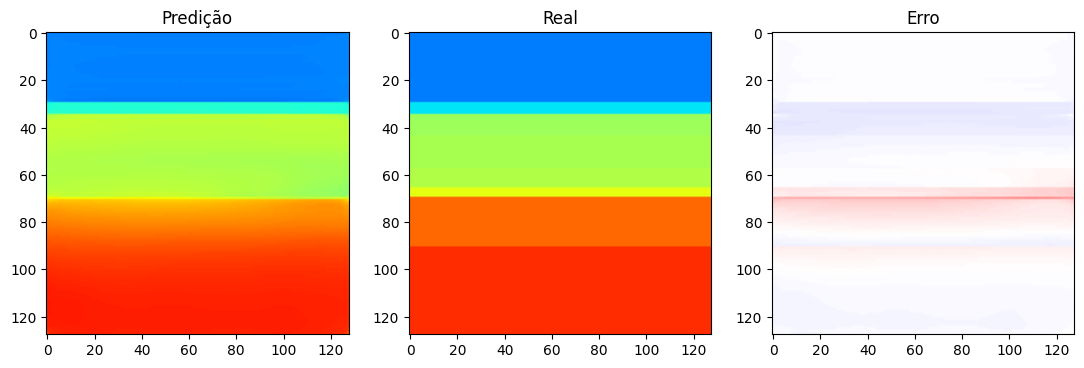

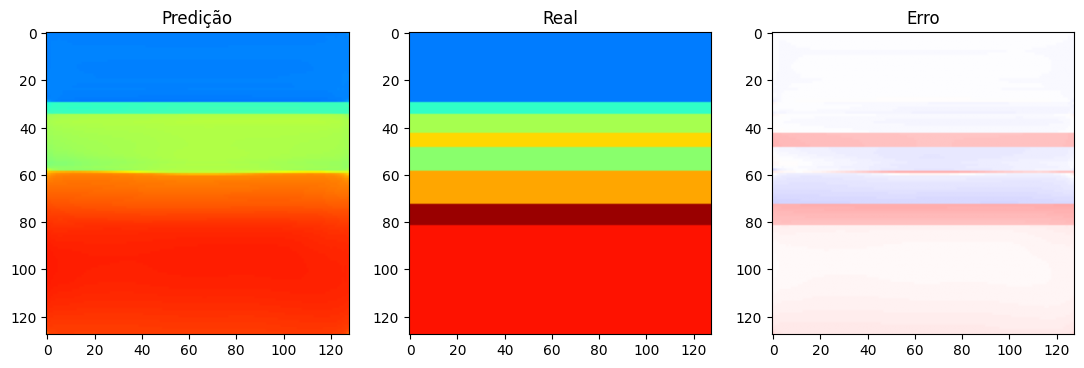

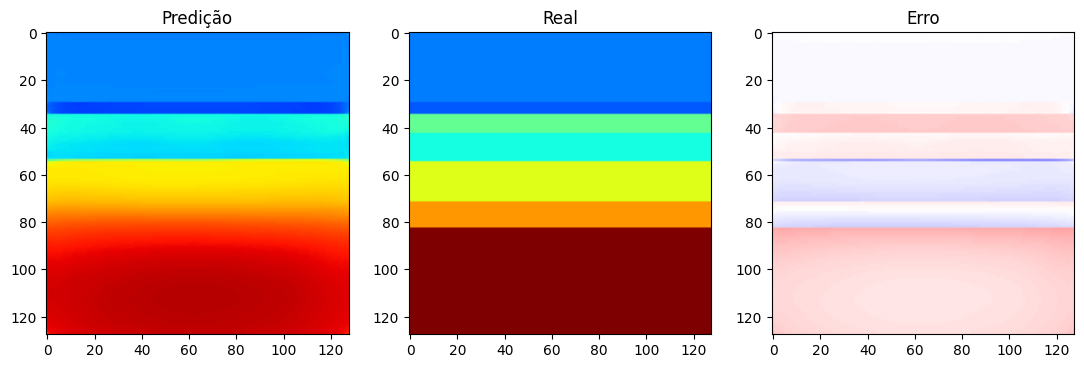

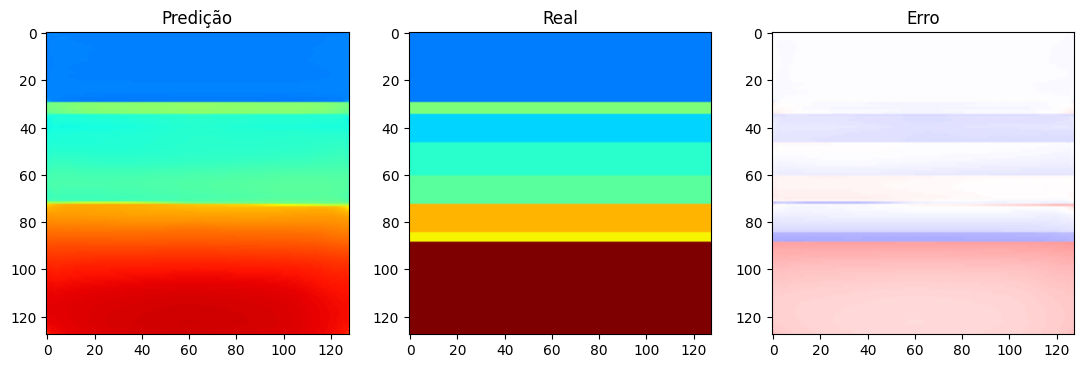

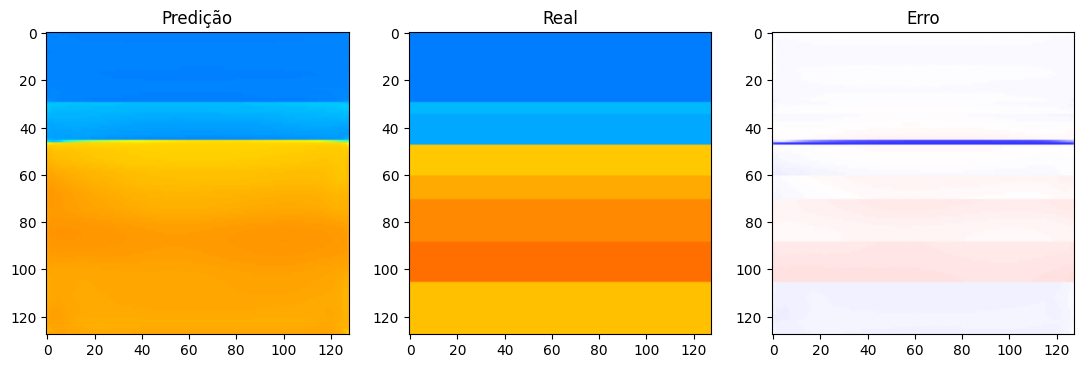

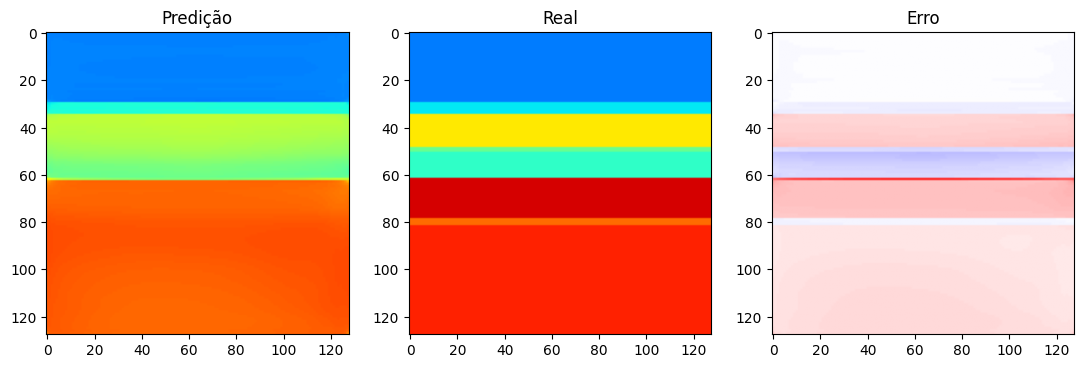

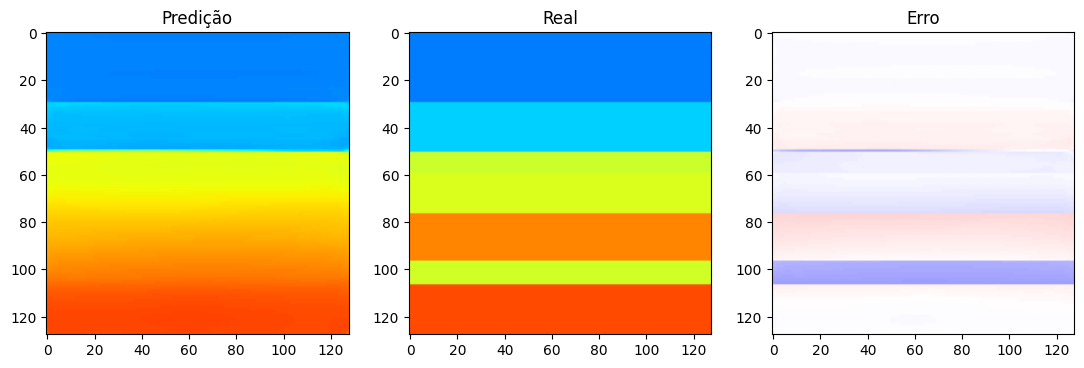

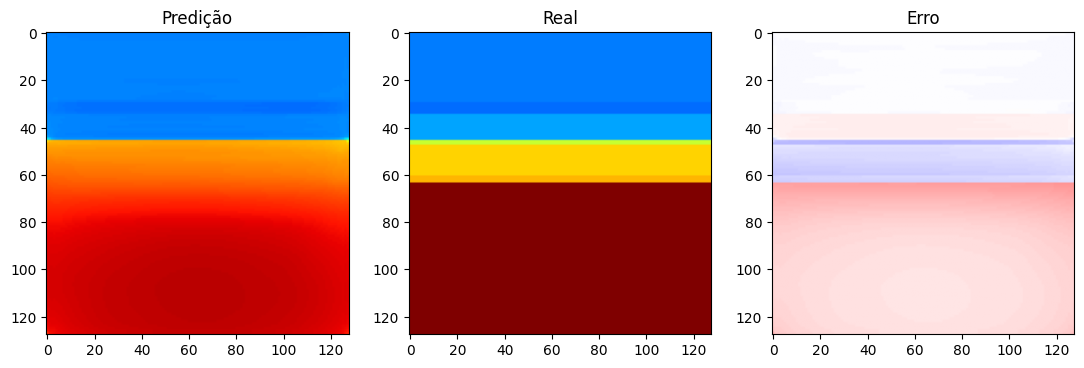

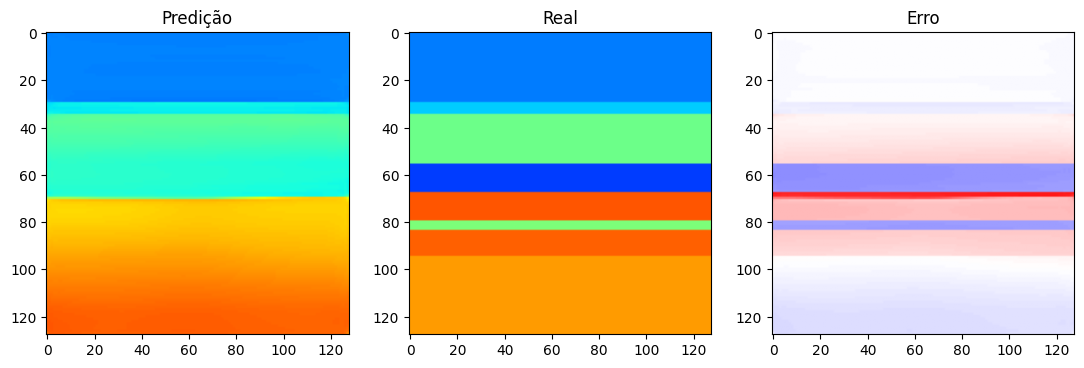

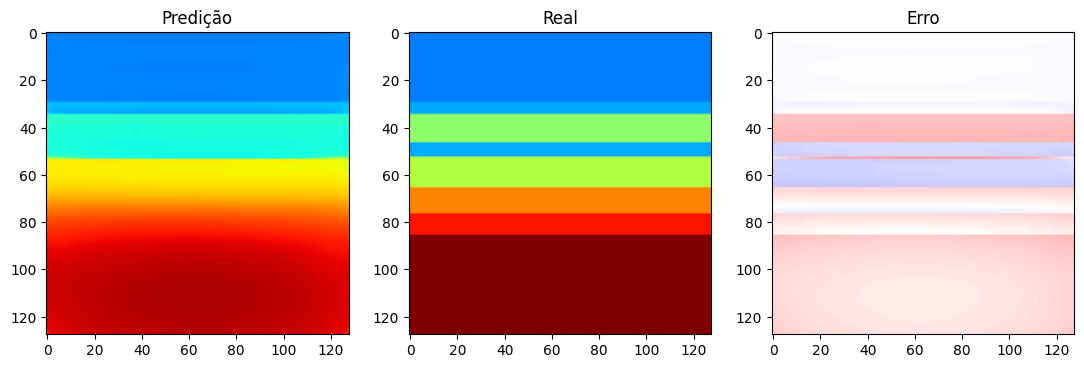

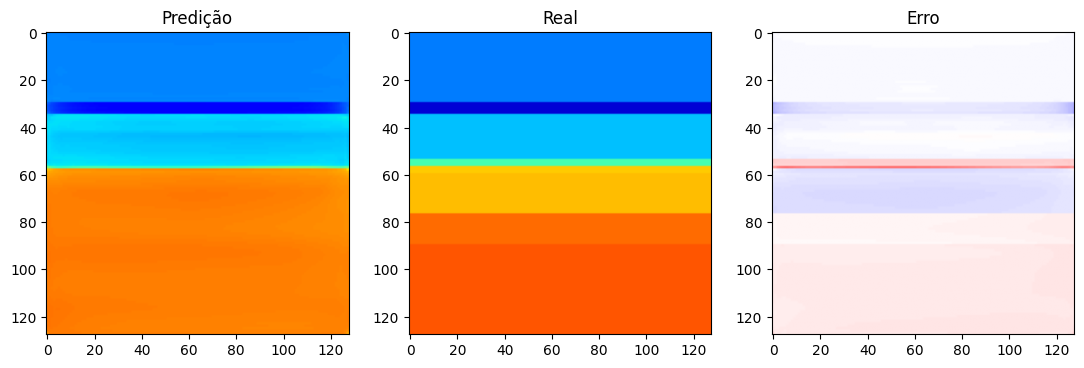

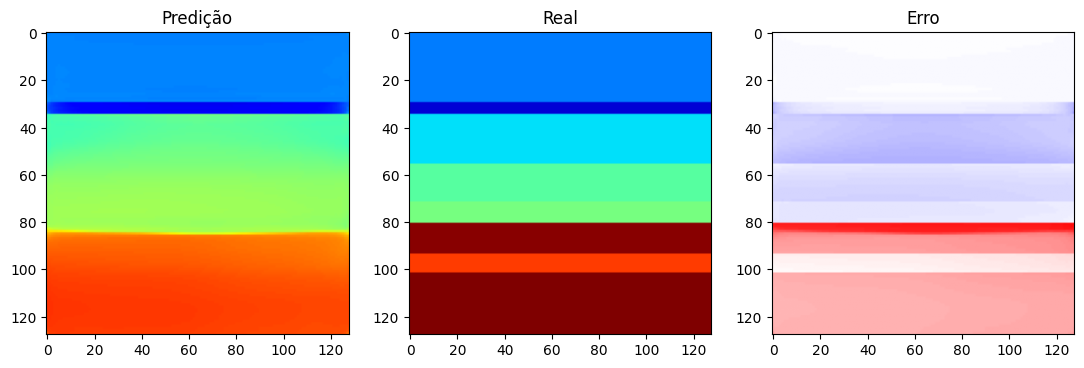

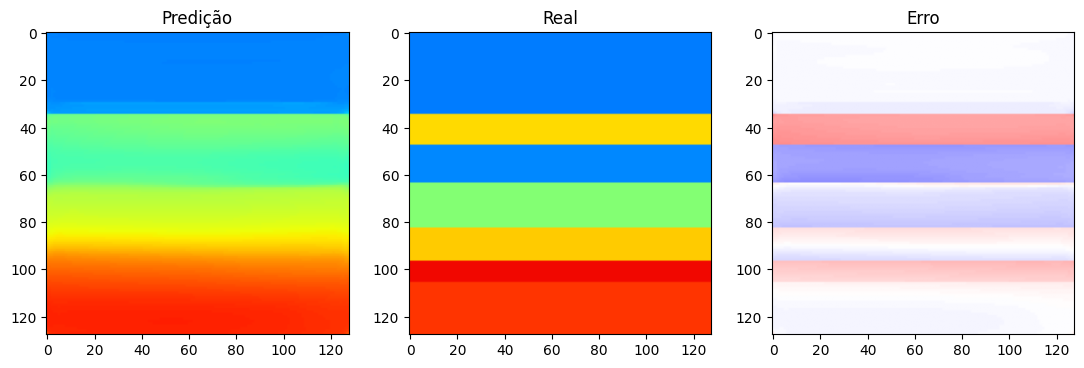

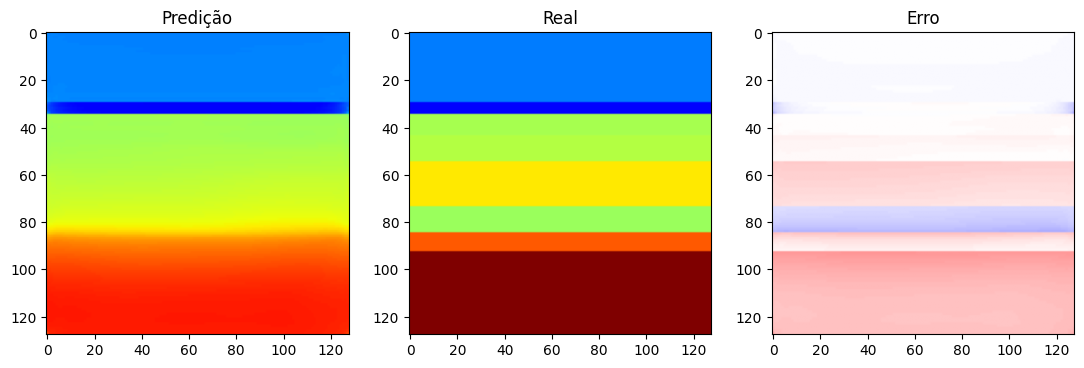

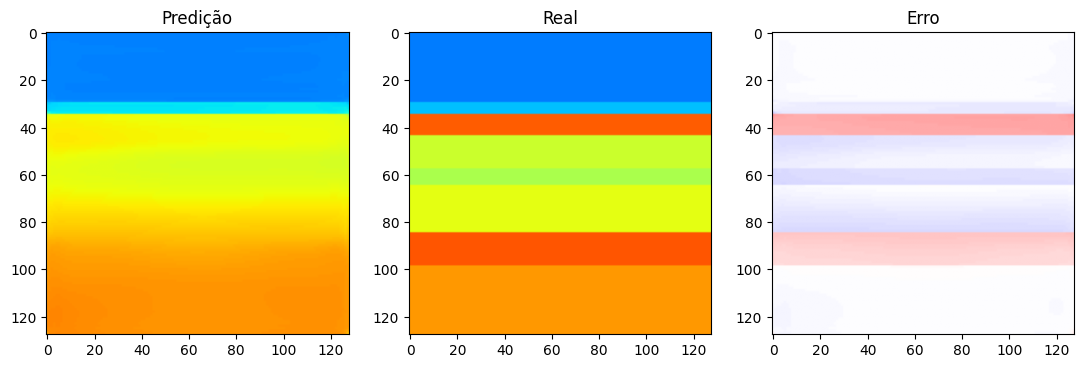

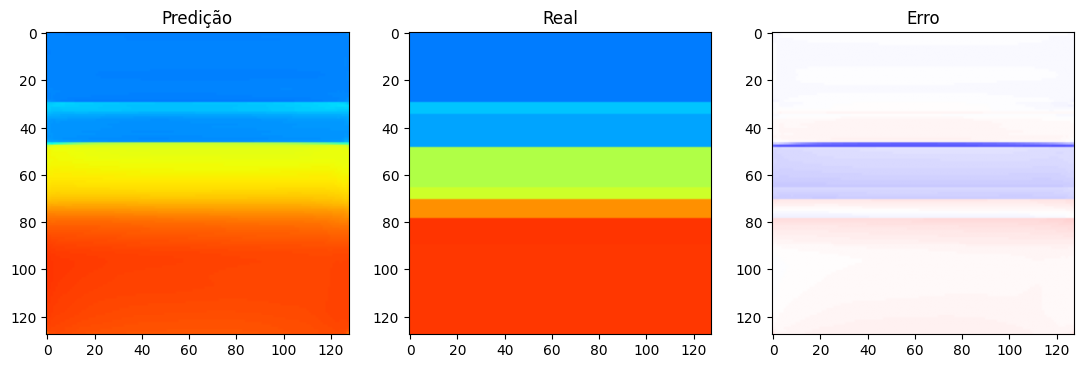

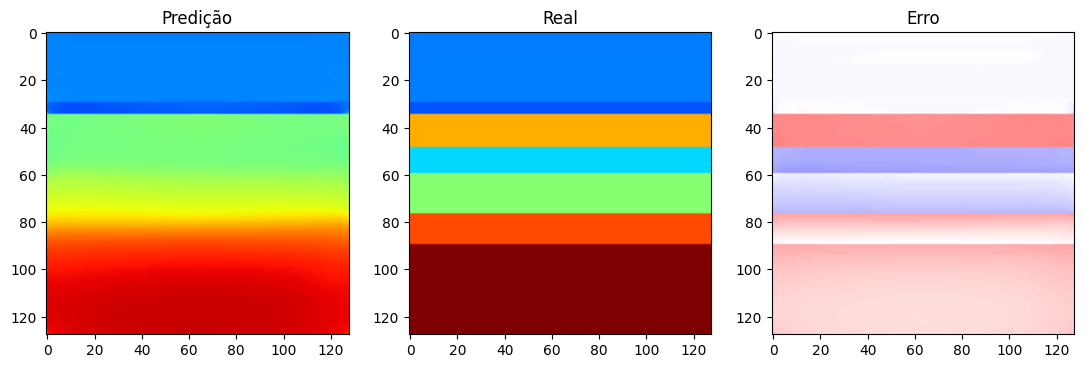

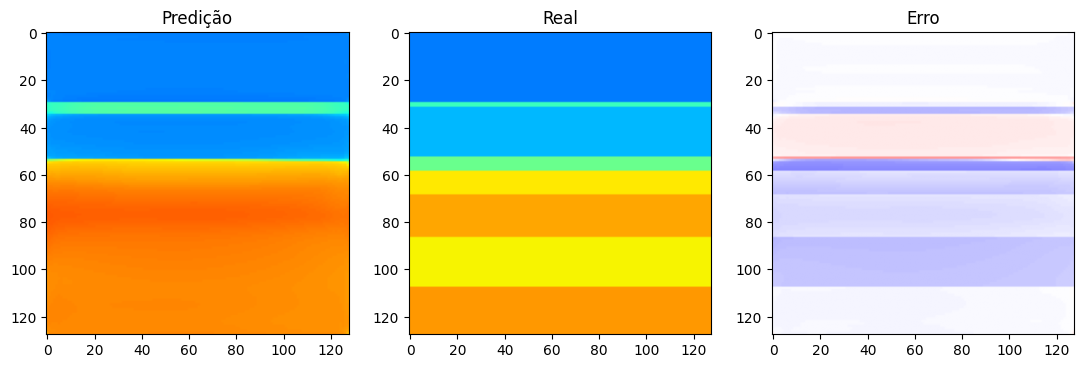

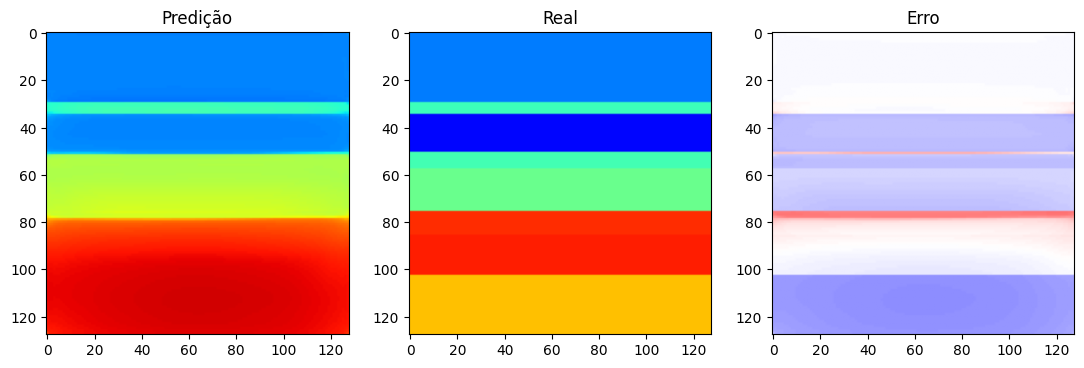

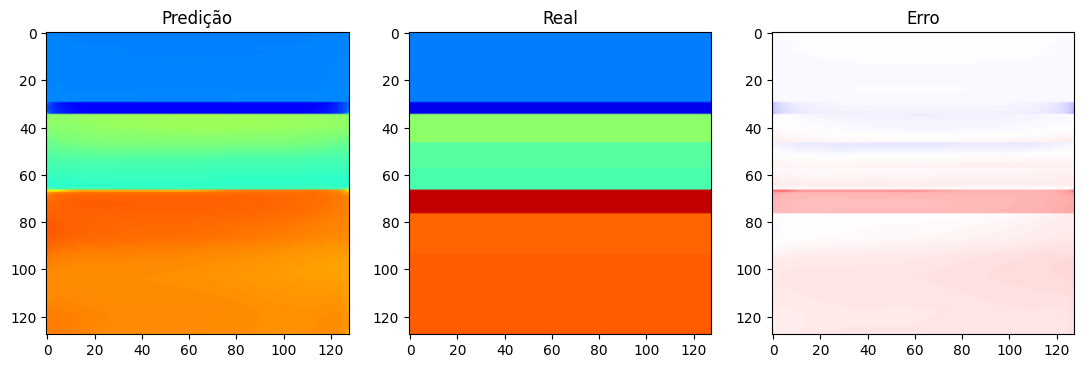

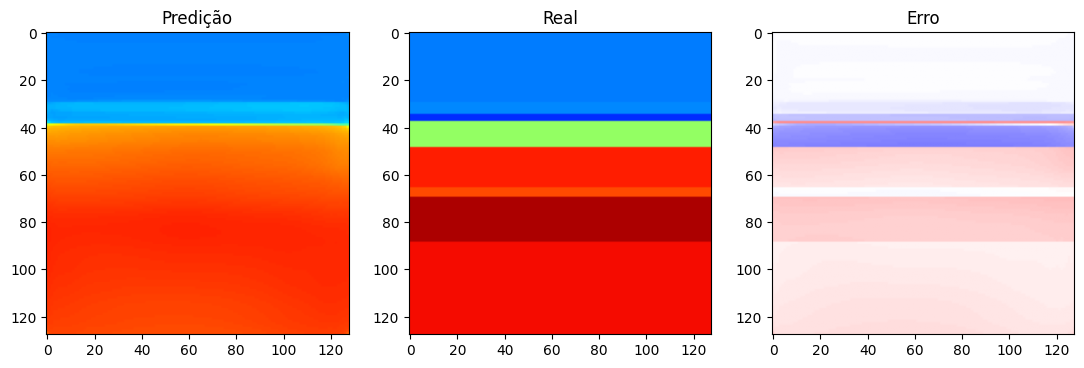

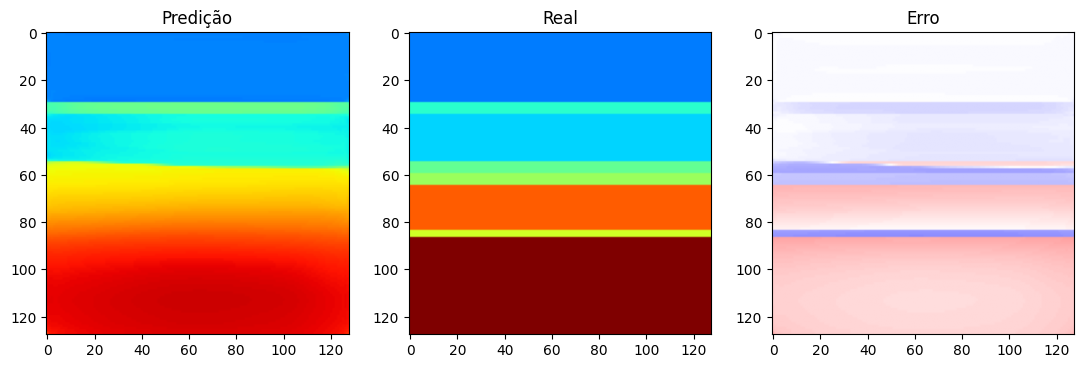

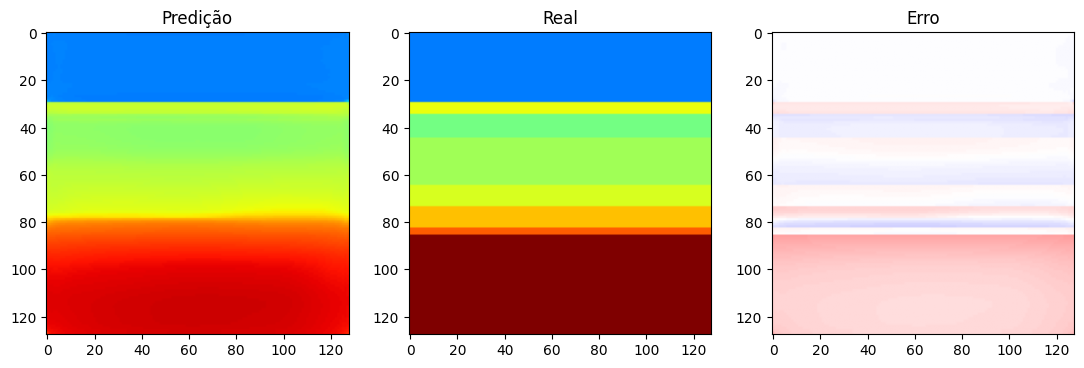

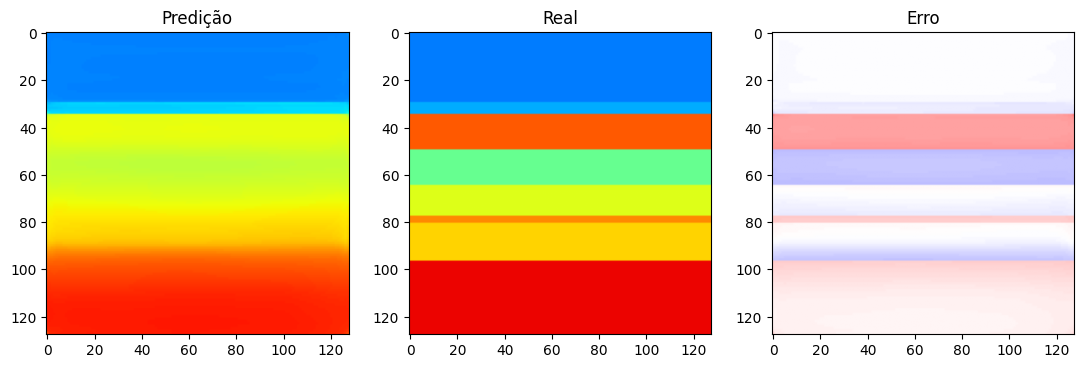

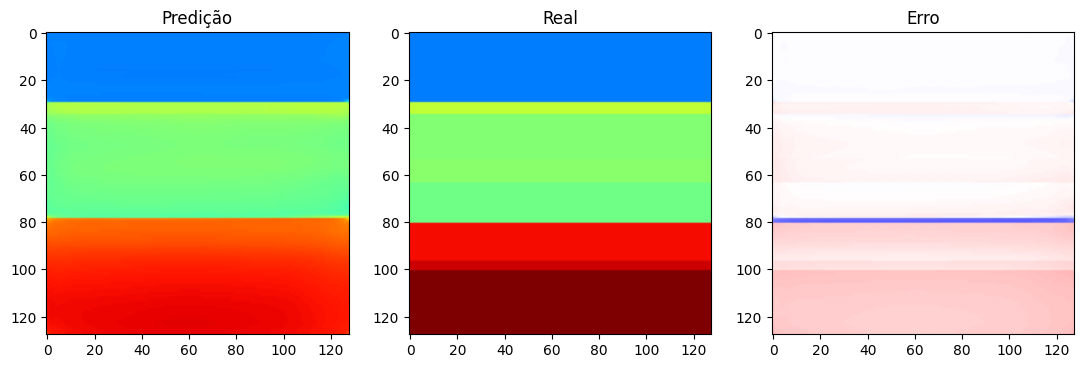

In [31]:
model.load_state_dict(torch.load("model_teste01.pth"))
model.eval()
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()

for i in range(len(x_test)):
    n_image = i#np.random.randint(0,len(pred))
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 7)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(pred_cpu[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:], cmap="seismic",vmin=-1,vmax=1)
    ax3.set_title('Erro')
    fig = plt.gcf()
    plt.show()